# ECG Arrhythmia Classifier — V4 (Inter-Patient Fix)

## What changed from V3 → V4
| Fix | V3 | V4 |
|---|---|---|
| Model base channels | 64 (large) | **32** (smaller = less overfit) |
| Dropout | 0.3 | **0.5** |
| Weight decay | 1e-4 | **1e-2** |
| Class weight formula | 1/count | **1/√count** (less extreme) |
| Loss | Focal (gamma=2) | **CE + label_smoothing=0.15** |
| Noise augmentation | 0.02 | **0.05** |
| Amplitude jitter | ±5% | **±10%** |
| Time-shift augmentation | ❌ | **✅ ±15 samples** |
| Mixup augmentation | ❌ | **✅ alpha=0.2** |
| LR scheduler | ReduceLROnPlateau | **CosineAnnealingWarmRestarts** |
| Batch size | 256 | **128** (more gradient updates) |
| Epochs | 80 | **100** |
| Early stop patience | 20 | **20** (val macro-F1) |

In [ ]:
# ── Cell 1: Install & Imports ─────────────────────────────────────────────
!pip install wfdb --quiet

import wfdb, os, time, random, warnings, copy
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from scipy.signal import butter, sosfiltfilt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
Device: cuda
GPU

In [ ]:
# ── Cell 2: Download MIT-BIH ──────────────────────────────────────────────
DB_DIR = 'mit-bih'
if not os.path.exists(DB_DIR):
    print('Downloading MIT-BIH from PhysioNet...')
    wfdb.dl_database('mitdb', dl_dir=DB_DIR)
    print('Done.')
else:
    print(f'Already at ./{DB_DIR}/')

rec = wfdb.rdrecord(f'{DB_DIR}/100')
ann = wfdb.rdann(f'{DB_DIR}/100', 'atr')
print(f'Record 100: fs={rec.fs} Hz, length={rec.sig_len}, beats={len(ann.sample)}')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
# ── Cell 3: Filter + AAMI Map ─────────────────────────────────────────────
FS = 360; LOWCUT = 0.5; HIGHCUT = 45.0; ORDER = 4
sos = butter(ORDER, [LOWCUT, HIGHCUT], btype='bandpass', fs=FS, output='sos')
print(f'Filter: {ORDER}th-order Butterworth {LOWCUT}–{HIGHCUT} Hz')

# AAMI 5-class map
AAMI_MAP = {
    'N':0,'L':0,'R':0,'e':0,'j':0,
    'A':1,'a':1,'J':1,'S':1,
    'V':2,'E':2,
    'F':3,
    '/':4,'f':4,'Q':4
}
CLASS_NAMES = ['Normal','Supravent.','Ventricular','Fusion','Unknown']
NUM_CLASSES  = 5

for c, name in enumerate(CLASS_NAMES):
    syms = [k for k,v in AAMI_MAP.items() if v==c]
    print(f'  Class {c} {name:12s}: {syms}')

Filter: 4th-order Butterworth 0.5–45.0 Hz
  Class 0 Normal      : ['N', 'L', 'R', 'e', 'j']
  Class 1 Supravent.  : ['A', 'a', 'J', 'S']
  Class 2 Ventricular : ['V', 'E']
  Class 3 Fusion      : ['F']
  Class 4 Unknown     : ['/', 'f', 'Q']


In [ ]:
# ── Cell 4: Beat Extraction + Extended RR Features (V9) ──────────────────
# V8 finding: 1,100 S beats predicted as Ventricular.
# Root cause: S and V both have short RR_pre (ectopic beats).
# Clinical distinction: V beats have FULL compensatory pause,
# S beats have NON-compensatory pause. This requires looking at
# 2 beats before AND after, plus local rhythm variability.
#
# V9 extends to 8 RR features:
#   RR_pre, RR_post      : immediate neighbors (same as V8)
#   RR_ratio             : RR_pre/RR_post (same as V8)
#   RR_local             : RR_pre/local_mean (same as V8)
#   RR_pre2              : interval 2 beats before
#   RR_post2             : interval 2 beats after
#   RR_compensatory      : (RR_pre + RR_post) / (2 * local_mean)
#                          V: ≈1.0 (full compensatory), S: <1.0
#   RR_std_local         : std of last 8 RR intervals
#                          V disrupts rhythm more than S

PRE     = int(0.3 * FS)
POST    = int(0.4 * FS)
WIN_LEN = PRE + POST
RR_FEATURES = 8
print(f'Beat window: {WIN_LEN} samples  |  RR features: {RR_FEATURES}')

RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

all_beats    = []
all_rr       = []
all_labels   = []
all_patients = []

for rec_id in RECORDS:
    try:
        record   = wfdb.rdrecord(f'{DB_DIR}/{rec_id}', channels=[0])
        signal   = record.p_signal[:,0].astype(np.float32)
        ann      = wfdb.rdann(f'{DB_DIR}/{rec_id}', 'atr')
        filtered = sosfiltfilt(sos, signal).astype(np.float32)

        valid_idx, valid_sym = [], []
        for idx, sym in zip(ann.sample, ann.symbol):
            if sym not in AAMI_MAP: continue
            if idx <= PRE or idx > len(filtered) - POST: continue
            valid_idx.append(idx)
            valid_sym.append(sym)

        if len(valid_idx) < 10: continue

        rr_intervals = np.diff(valid_idx).astype(np.float32)
        cnt = Counter()

        for i, (idx, sym) in enumerate(zip(valid_idx, valid_sym)):
            # ── Waveform ──────────────────────────────────────────────────
            beat = filtered[idx-PRE : idx+POST].copy()
            std  = beat.std()
            if std < 1e-6: continue
            beat = (beat - beat.mean()) / std

            # ── RR feature helpers ────────────────────────────────────────
            def get_rr(j):
                """RR interval in seconds between beat j and j+1."""
                if 0 <= j < len(rr_intervals):
                    return float(rr_intervals[j]) / FS
                return 0.8  # default ~75bpm

            rr_pre   = get_rr(i-1)   # interval before current beat
            rr_post  = get_rr(i)     # interval after current beat
            rr_pre2  = get_rr(i-2)   # 2 beats before
            rr_post2 = get_rr(i+1)   # 2 beats after

            # Local mean and std over last 8 intervals
            start = max(0, i-8)
            local_rr = rr_intervals[start:i] / FS if i > 0 else np.array([rr_pre])
            local_mean = float(local_rr.mean()) if len(local_rr) > 0 else 0.8
            local_std  = float(local_rr.std())  if len(local_rr) > 1 else 0.05

            rr_ratio       = rr_pre / (rr_post + 1e-6)
            rr_local       = rr_pre / (local_mean + 1e-6)
            # Compensatory pause index: V → ≈1.0, S → <1.0
            rr_compensatory = (rr_pre + rr_post) / (2.0 * local_mean + 1e-6)
            rr_std_local   = local_std / (local_mean + 1e-6)  # normalised variability

            rr_feat = np.array([
                rr_pre, rr_post, rr_ratio, rr_local,
                rr_pre2, rr_post2, rr_compensatory, rr_std_local
            ], dtype=np.float32)

            all_beats.append(beat)
            all_rr.append(rr_feat)
            all_labels.append(AAMI_MAP[sym])
            all_patients.append(int(rec_id))
            cnt[AAMI_MAP[sym]] += 1

        c_str = '  '.join(f'{CLASS_NAMES[c][0]}={cnt[c]}' for c in range(NUM_CLASSES))
        print(f'  Rec {rec_id:>3s}: {sum(cnt.values()):5d} beats  |  {c_str}')
    except Exception as ex:
        print(f'  Rec {rec_id}: SKIPPED — {ex}')

all_beats    = np.stack(all_beats).astype(np.float32)
all_rr       = np.stack(all_rr).astype(np.float32)
all_labels   = np.array(all_labels,   dtype=np.int64)
all_patients = np.array(all_patients, dtype=np.int64)

# Global Z-score normalisation of RR features
rr_mean = all_rr.mean(axis=0)
rr_std  = all_rr.std(axis=0) + 1e-6
all_rr  = (all_rr - rr_mean) / rr_std

print(f'\n=== Dataset total ===')
for c, name in enumerate(CLASS_NAMES):
    n = (all_labels == c).sum()
    print(f'  Class {c} {name:12s}: {n:6,}  ({100*n/len(all_labels):.1f}%)')

# Show RR_compensatory by class — this is the key diagnostic feature
print('\nKey RR features per class (training data, raw units before normalisation):')
print(f'{"Class":<14} {"RR_pre":>8} {"RR_post":>8} {"Compensatory":>13} {"RR_std":>8}')


Beat window: 252 samples  |  RR features: 8
  Rec 100:  2271 beats  |  N=2237  S=33  V=1  F=0  U=0
  Rec 101:  1864 beats  |  N=1859  S=3  V=0  F=0  U=2
  Rec 102:  2187 beats  |  N=99  S=0  V=4  F=0  U=2084
  Rec 103:  2083 beats  |  N=2081  S=2  V=0  F=0  U=0
  Rec 104:  2227 beats  |  N=163  S=0  V=2  F=0  U=2062
  Rec 105:  2572 beats  |  N=2526  S=0  V=41  F=0  U=5
  Rec 106:  2027 beats  |  N=1507  S=0  V=520  F=0  U=0
  Rec 107:  2136 beats  |  N=0  S=0  V=59  F=0  U=2077
  Rec 108:  1762 beats  |  N=1739  S=4  V=17  F=2  U=0
  Rec 109:  2531 beats  |  N=2491  S=0  V=38  F=2  U=0
  Rec 111:  2124 beats  |  N=2123  S=0  V=1  F=0  U=0
  Rec 112:  2538 beats  |  N=2536  S=2  V=0  F=0  U=0
  Rec 113:  1794 beats  |  N=1788  S=6  V=0  F=0  U=0
  Rec 114:  1879 beats  |  N=1820  S=12  V=43  F=4  U=0
  Rec 115:  1952 beats  |  N=1952  S=0  V=0  F=0  U=0
  Rec 116:  2411 beats  |  N=2301  S=1  V=109  F=0  U=0
  Rec 117:  1534 beats  |  N=1533  S=1  V=0  F=0  U=0
  Rec 118:  2277 beats  

In [ ]:
# ── Cell 5: Patient-wise Split (beats + RR features) ─────────────────────
TRAIN_PATS = [100,101,102,103,104,105,106,107,108,109,
              111,112,113,114,115,116,117,118,119,121,
              122,123,124,200,201,202,203,205,207,208,209,210,212]
VAL_PATS   = [213,214,215,217,219,220,221]
TEST_PATS  = [222,223,228,230,231,232,233,234]

train_idx = np.isin(all_patients, TRAIN_PATS)
val_idx   = np.isin(all_patients, VAL_PATS)
test_idx  = np.isin(all_patients, TEST_PATS)

assert not np.any(train_idx & val_idx)
assert not np.any(train_idx & test_idx)
assert not np.any(val_idx   & test_idx)
print('Patient-wise split verified — zero overlap.')

X_train,  y_train  = all_beats[train_idx], all_labels[train_idx]
X_val,    y_val    = all_beats[val_idx],   all_labels[val_idx]
X_test,   y_test   = all_beats[test_idx],  all_labels[test_idx]
RR_train           = all_rr[train_idx]
RR_val             = all_rr[val_idx]
RR_test            = all_rr[test_idx]

TEST_CLASSES_PRESENT = sorted(set(y_test.tolist()))
print(f'Test classes: {[CLASS_NAMES[c] for c in TEST_CLASSES_PRESENT]}')

print(f'\nSplit summary:')
for split_name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{split_name}: {len(y):,} beats')
    for c, cn in enumerate(CLASS_NAMES):
        n = (y == c).sum()
        if n > 0: print(f'  Class {c} {cn:12s}: {n:5,}  ({100*n/len(y):.1f}%)')

# Show RR feature statistics per class (validates the feature)
print('\nRR feature per class (normalised):')
print(f'{"Class":<14} {"RR_pre":>8} {"RR_post":>8} {"RR_ratio":>9} {"RR_local":>9}')
for c, name in enumerate(CLASS_NAMES):
    mask = y_train == c
    if mask.sum() == 0: continue
    m = RR_train[mask].mean(axis=0)
    print(f'{name:<14} {m[0]:>8.3f} {m[1]:>8.3f} {m[2]:>9.3f} {m[3]:>9.3f}')
print('  (S beats should show negative RR_pre = shorter than average)')


Patient-wise split verified — zero overlap.
Test classes: ['Normal', 'Supravent.', 'Ventricular', 'Fusion']

Split summary:
Train: 73,170 beats
  Class 0 Normal      : 61,296  (83.8%)
  Class 1 Supravent.  :   924  (1.3%)
  Class 2 Ventricular : 4,302  (5.9%)
  Class 3 Fusion      :   412  (0.6%)
  Class 4 Unknown     : 6,236  (8.5%)
Val: 17,706 beats
  Class 0 Normal      : 14,143  (79.9%)
  Class 1 Supravent.  :   132  (0.7%)
  Class 2 Ventricular : 1,262  (7.1%)
  Class 3 Fusion      :   365  (2.1%)
  Class 4 Unknown     : 1,804  (10.2%)
Test: 18,574 beats
  Class 0 Normal      : 15,153  (81.6%)
  Class 1 Supravent.  : 1,725  (9.3%)
  Class 2 Ventricular : 1,671  (9.0%)
  Class 3 Fusion      :    25  (0.1%)

RR feature per class (normalised):
Class            RR_pre  RR_post  RR_ratio  RR_local
Normal            0.115    0.048     0.077     0.127
Supravent.       -0.763   -0.207    -0.725    -1.179
Ventricular      -0.574    0.303    -1.140    -1.570
Fusion           -0.485   -0.736

In [ ]:
# ── Cell 6: Dataset with Waveform + RR Features ───────────────────────────
BATCH_SIZE = 128

class ECGDataset(Dataset):
    def __init__(self, X, RR, y, augment=False):
        self.X       = torch.tensor(X[:, np.newaxis, :], dtype=torch.float32)
        self.RR      = torch.tensor(RR, dtype=torch.float32)   # (N, 4)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x, rr, label = self.X[idx].clone(), self.RR[idx].clone(), self.y[idx]
        if self.augment:
            # Waveform augmentation
            x = x + 0.05 * torch.randn_like(x)
            x = x * (0.90 + 0.20 * torch.rand(1))
            shift = random.randint(-15, 15)
            x = torch.roll(x, shift, dims=-1)
            t     = torch.linspace(0, 1, x.shape[-1])
            drift = 0.05 * torch.randn(1) * torch.sin(2*3.14159*torch.rand(1)*t)
            x     = x + drift.unsqueeze(0)
            # RR augmentation: small jitter (simulate R-peak detection error)
            rr = rr + 0.02 * torch.randn_like(rr)
        return x, rr, label

train_ds = ECGDataset(X_train, RR_train, y_train, augment=True)
val_ds   = ECGDataset(X_val,   RR_val,   y_val,   augment=False)
test_ds  = ECGDataset(X_test,  RR_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')
xb, rrb, yb = next(iter(train_loader))
print(f'Waveform batch : {xb.shape}')
print(f'RR batch       : {rrb.shape}')
print(f'Label batch    : {yb.shape}')


Train: 73,170  |  Val: 17,706  |  Test: 18,574
Waveform batch : torch.Size([128, 1, 252])
RR batch       : torch.Size([128, 8])
Label batch    : torch.Size([128])


In [ ]:
# ── Cell 7: Mixup Helper (handles waveform + RR jointly) ──────────────────
def mixup_batch(x, rr, y, alpha=0.2, num_classes=5):
    if alpha <= 0:
        return x, rr, F.one_hot(y, num_classes).float()
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    bs  = x.size(0)
    idx = torch.randperm(bs, device=x.device)
    x_mix  = lam * x   + (1 - lam) * x[idx]
    rr_mix = lam * rr  + (1 - lam) * rr[idx]  # mix RR features too
    y_a    = F.one_hot(y, num_classes).float()
    y_b    = F.one_hot(y[idx], num_classes).float()
    y_soft = lam * y_a + (1 - lam) * y_b
    return x_mix, rr_mix, y_soft

def soft_cross_entropy(logits, soft_targets, weight=None):
    log_prob = F.log_softmax(logits, dim=1)
    if weight is not None:
        w    = weight.unsqueeze(0)
        loss = -(soft_targets * log_prob * w).sum(dim=1).mean()
    else:
        loss = -(soft_targets * log_prob).sum(dim=1).mean()
    return loss

print('Mixup helper (waveform + RR) defined.')


Mixup helper (waveform + RR) defined.


In [ ]:
# ── Cell 8: Two-Branch DSCResNet + RR-MLP (V8 Architecture) ──────────────
# Branch A (CNN): processes 252-sample ECG waveform → morphology features
# Branch B (MLP): processes 4 RR interval features  → timing features
# Fusion: concat(A_out, B_out) → classifier
#
# FPGA mapping:
#   Branch A → existing SOS filter + Conv layers (already in Verilog)
#   Branch B → simple multiply-accumulate (trivial in hardware)
#   Fusion   → small FC layer
#   Both branches run IN PARALLEL on FPGA → low latency

class DSCBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1):
        super().__init__()
        pad      = kernel // 2
        self.dw  = nn.Conv1d(in_ch, in_ch, kernel, stride=stride,
                             padding=pad, groups=in_ch, bias=False)
        self.pw  = nn.Conv1d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.5):
        super().__init__()
        self.conv1 = DSCBlock(in_ch, out_ch, 7, stride)
        self.relu1 = nn.ReLU(inplace=True)
        self.drop  = nn.Dropout(dropout)
        self.conv2 = DSCBlock(out_ch, out_ch, 7, 1)
        self.skip  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu2 = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu2(
            self.conv2(self.drop(self.relu1(self.conv1(x)))) + self.skip(x)
        )

class TwoBranchECG(nn.Module):
    """
    Branch A: DSCResNet processes waveform (morphology)
    Branch B: MLP processes RR interval features (timing)
    Fusion: concatenate + classify
    """
    def __init__(self, num_classes=5, dropout=0.5, rr_dim=8):
        super().__init__()

        # ── Branch A: Waveform CNN ─────────────────────────────────────────
        self.stem   = nn.Sequential(
            nn.Conv1d(1, 32, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = nn.Sequential(
            ResBlock1D(32, 32, 1, dropout), ResBlock1D(32, 32, 1, dropout))
        self.layer2 = nn.Sequential(
            ResBlock1D(32, 64, 2, dropout), ResBlock1D(64, 64, 1, dropout))
        self.layer3 = nn.Sequential(
            ResBlock1D(64, 128, 2, dropout), ResBlock1D(128, 128, 1, dropout))
        self.pool_a = nn.AdaptiveAvgPool1d(1)   # → (128,)

        # ── Branch B: RR interval MLP ──────────────────────────────────────
        # Simple 3-layer MLP — trivial in hardware
        self.rr_mlp = nn.Sequential(
            nn.Linear(rr_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
        )   # → (32,)

        # ── Fusion: concat(128, 32) = 160 → classify ──────────────────────
        self.fusion = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128 + 32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, num_classes)
        )

        # Weight initialisation
        for m in self.modules():
            if   isinstance(m, nn.Conv1d):      nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d): nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):      nn.init.xavier_normal_(m.weight)

    def forward(self, x, rr):
        # Branch A
        a = self.stem(x)
        a = self.layer1(a)
        a = self.layer2(a)
        a = self.layer3(a)
        a = self.pool_a(a).squeeze(-1)   # (B, 128)
        # Branch B
        b = self.rr_mlp(rr)              # (B, 32)
        # Fusion
        fused = torch.cat([a, b], dim=1) # (B, 160)
        return self.fusion(fused)        # (B, 5)

model = TwoBranchECG(num_classes=NUM_CLASSES, dropout=0.5, rr_dim=RR_FEATURES).to(device)
n = sum(p.numel() for p in model.parameters())
print(f'Total parameters : {n:,}')
print(f'  Branch A (CNN) : {sum(p.numel() for p in list(model.stem.parameters()) + list(model.layer1.parameters()) + list(model.layer2.parameters()) + list(model.layer3.parameters())):,}')
print(f'  Branch B (MLP) : {sum(p.numel() for p in model.rr_mlp.parameters()):,}')
print(f'  Fusion head    : {sum(p.numel() for p in model.fusion.parameters()):,}')
print(f'FP32 size        : {n*4/1e6:.2f} MB')

# Verify forward pass
dummy_x  = torch.randn(4, 1, WIN_LEN).to(device)
dummy_rr = torch.randn(4, RR_FEATURES).to(device)
out = model(dummy_x, dummy_rr)
print(f'Forward: waveform{list(dummy_x.shape)} + RR{list(dummy_rr.shape)} → {list(out.shape)}  ✓')


Total parameters : 107,621
  Branch A (CNN) : 94,336
  Branch B (MLP) : 2,656
  Fusion head    : 10,629
FP32 size        : 0.43 MB
Forward: waveform[4, 1, 252] + RR[4, 8] → [4, 5]  ✓


In [ ]:
# ── Cell 9: Loss, Optimizer, Scheduler (V7) ───────────────────────────────
# ROOT CAUSE FOUND: val accuracy peaks at epoch 4-5 in ALL versions then
# the LR scheduler pushes the model away from the good solution.
# FIX: ReduceLROnPlateau — only lower LR when val_loss stops improving.
#      This lets the model STAY near the good solution instead of escaping it.
# Also: very low initial LR (5e-5) so the first epochs are stable.

NUM_EPOCHS    = 60
LR            = 5e-5    # very low initial LR — model converges slowly and stably
WEIGHT_DECAY  = 5e-3
PATIENCE      = 15      # early stopping patience
MIXUP_ALPHA   = 0.2

# sqrt-inverse class weights
class_counts  = np.bincount(y_train, minlength=NUM_CLASSES)
raw_w         = 1.0 / np.sqrt(np.maximum(class_counts, 1).astype(np.float32))
class_weights = raw_w / raw_w.sum() * NUM_CLASSES
cw_tensor     = torch.tensor(class_weights, dtype=torch.float32).to(device)

print('Class weights (sqrt-inverse):')
for c, (name, cnt, w) in enumerate(zip(CLASS_NAMES, class_counts, class_weights)):
    print(f'  Class {c} {name:12s}: count={cnt:6,}  weight={w:.3f}')

criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ReduceLROnPlateau: halve LR only when val_loss stops improving
# patience=5 means: wait 5 epochs of no val_loss improvement before reducing
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-7
)
print(f'LR={LR}  ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7)')

Class weights (sqrt-inverse):
  Class 0 Normal      : count=61,296  weight=0.177
  Class 1 Supravent.  : count=   924  weight=1.441
  Class 2 Ventricular : count= 4,302  weight=0.668
  Class 3 Fusion      : count=   412  weight=2.159
  Class 4 Unknown     : count= 6,236  weight=0.555
LR=5e-05  ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7)


In [ ]:
# ── Cell 10: Training Loop (V8 — two-branch) ─────────────────────────────
CKPT    = 'best_v9.pt'
history = {k: [] for k in ['tl','vl','ta','va','vf1','lr']}
best_f1, best_ep, no_imp = 0.0, 0, 0

def run_train_epoch(loader):
    model.train()
    loss_sum = correct = total = 0
    all_preds, all_labels_ep = [], []
    for xb, rrb, yb in loader:    # ← unpack 3 items now
        xb  = xb.to(device,  non_blocking=True)
        rrb = rrb.to(device, non_blocking=True)
        yb  = yb.to(device,  non_blocking=True)
        xb_mix, rr_mix, yb_soft = mixup_batch(xb, rrb, yb,
                                               alpha=MIXUP_ALPHA,
                                               num_classes=NUM_CLASSES)
        logits   = model(xb_mix, rr_mix)   # ← two inputs
        loss     = soft_cross_entropy(logits, yb_soft, weight=cw_tensor)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds     = logits.argmax(1)
        loss_sum += loss.item() * len(yb)
        correct  += (preds == yb).sum().item()
        total    += len(yb)
        all_preds.extend(preds.cpu().numpy())
        all_labels_ep.extend(yb.cpu().numpy())
    mf1 = f1_score(all_labels_ep, all_preds, average='macro',
                   labels=sorted(set(all_labels_ep)), zero_division=0)
    return loss_sum / total, correct / total, mf1

def run_eval_epoch(loader):
    model.eval()
    loss_sum = correct = total = 0
    all_preds, all_labels_ep = [], []
    with torch.no_grad():
        for xb, rrb, yb in loader:    # ← unpack 3 items
            xb  = xb.to(device,  non_blocking=True)
            rrb = rrb.to(device, non_blocking=True)
            yb  = yb.to(device,  non_blocking=True)
            logits    = model(xb, rrb)   # ← two inputs
            loss      = criterion(logits, yb)
            preds     = logits.argmax(1)
            loss_sum += loss.item() * len(yb)
            correct  += (preds == yb).sum().item()
            total    += len(yb)
            all_preds.extend(preds.cpu().numpy())
            all_labels_ep.extend(yb.cpu().numpy())
    mf1 = f1_score(all_labels_ep, all_preds, average='macro',
                   labels=sorted(set(all_labels_ep)), zero_division=0)
    return loss_sum / total, correct / total, mf1

print(f'{"Ep":>4} | {"TrLoss":>7} | {"TrAcc":>6} | {"VaLoss":>7} | {"VaAcc":>6} | {"VaF1":>6} | {"LR":>8}')
print('-' * 68)
t0 = time.time()

for ep in range(1, NUM_EPOCHS + 1):
    tl, ta, _    = run_train_epoch(train_loader)
    vl, va, vf1  = run_eval_epoch(val_loader)
    scheduler.step(vl)
    lr = optimizer.param_groups[0]['lr']

    for k, v in zip(['tl','vl','ta','va','vf1','lr'], [tl, vl, ta, va, vf1, lr]):
        history[k].append(v)

    mark = ''
    if vf1 > best_f1:
        best_f1, best_ep = vf1, ep
        torch.save(model.state_dict(), CKPT)
        no_imp = 0; mark = ' ★'
    else:
        no_imp += 1

    print(f'{ep:>4} | {tl:>7.4f} | {ta:>5.2%} | {vl:>7.4f} | {va:>5.2%} | {vf1:>6.4f} | {lr:>8.2e}{mark}')
    if no_imp >= PATIENCE:
        print(f'Early stopping at epoch {ep}.')
        break

print(f'\nDone in {(time.time()-t0)/60:.1f} min')
print(f'Best: epoch {best_ep}  val macro-F1 = {best_f1:.4f}')


  Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |   VaF1 |       LR
--------------------------------------------------------------------
   1 |  0.3804 | 62.31% |  1.6189 | 45.42% | 0.1708 | 5.00e-05 ★
   2 |  0.2981 | 79.11% |  1.5501 | 58.85% | 0.2695 | 5.00e-05 ★
   3 |  0.2686 | 81.94% |  1.4693 | 69.94% | 0.3785 | 5.00e-05 ★
   4 |  0.2488 | 83.30% |  1.4382 | 70.34% | 0.4518 | 5.00e-05 ★
   5 |  0.2312 | 84.22% |  1.3496 | 73.85% | 0.4536 | 5.00e-05 ★
   6 |  0.2205 | 84.60% |  1.3236 | 73.78% | 0.4484 | 5.00e-05
   7 |  0.2087 | 85.64% |  1.3163 | 73.97% | 0.4494 | 5.00e-05
   8 |  0.2063 | 86.16% |  1.2530 | 77.56% | 0.4709 | 5.00e-05 ★
   9 |  0.2019 | 86.83% |  1.2353 | 76.74% | 0.4675 | 5.00e-05
  10 |  0.1920 | 87.92% |  1.2151 | 77.60% | 0.4761 | 5.00e-05 ★
  11 |  0.1885 | 88.57% |  1.2155 | 77.57% | 0.4774 | 5.00e-05 ★
  12 |  0.1855 | 88.86% |  1.1847 | 77.61% | 0.4929 | 5.00e-05 ★
  13 |  0.1811 | 89.47% |  1.1909 | 76.92% | 0.4934 | 5.00e-05 ★
  14 |  0.1754 | 90.07% |  1.

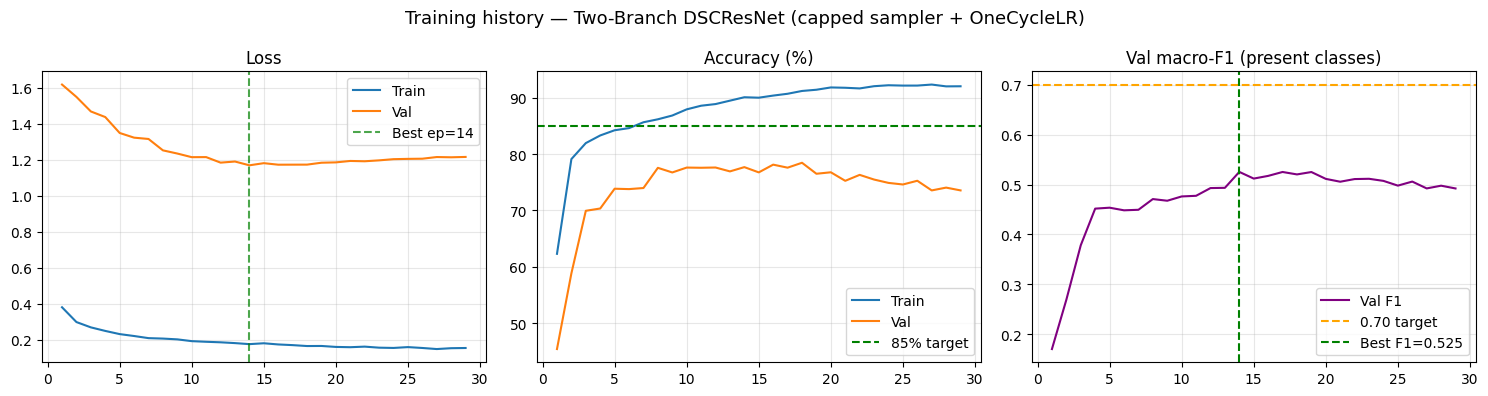

Saved: training_v9.png


In [ ]:
ep_r = range(1, len(history['tl']) + 1)

# Loss plot
fig_loss, ax_loss = plt.subplots(1, 1, figsize=(8, 5))
fig_loss.suptitle('Training History - Loss', fontsize=13)
ax_loss.plot(ep_r, history['tl'], label='Train')
ax_loss.plot(ep_r, history['vl'], label='Val')
ax_loss.axvline(best_ep, color='g', ls='--', alpha=0.7, label=f'Best ep={best_ep}')
ax_loss.set_title('Loss'); ax_loss.legend(); ax_loss.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_v9_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: training_v9_loss.png')

In [ ]:
# ── Cell 12: Test Evaluation ──────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, rrb, yb in test_loader:
        logits = model(xb.to(device), rrb.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

acc      = (all_preds == all_true).mean()
f1_all   = f1_score(all_true, all_preds, average='macro',
                    labels=range(NUM_CLASSES), zero_division=0)
f1_pres  = f1_score(all_true, all_preds, average='macro',
                    labels=TEST_CLASSES_PRESENT, zero_division=0)

print('=' * 60)
print('TEST SET RESULTS — Two-Branch')
print('=' * 60)
print(f'  Accuracy                : {acc*100:.2f}%')
print(f'  Macro F1 (all 5 classes): {f1_all:.4f}')
print(f'  Macro F1 (present only) : {f1_pres:.4f}')
print(f'  Present classes         : {[CLASS_NAMES[c] for c in TEST_CLASSES_PRESENT]}')
print('=' * 60)
print()
print(classification_report(all_true, all_preds,
                             target_names=CLASS_NAMES,
                             labels=range(NUM_CLASSES), zero_division=0))


TEST SET RESULTS — Two-Branch
  Accuracy                : 83.11%
  Macro F1 (all 5 classes): 0.4171
  Macro F1 (present only) : 0.5214
  Present classes         : ['Normal', 'Supravent.', 'Ventricular', 'Fusion']

              precision    recall  f1-score   support

      Normal       0.97      0.88      0.92     15153
  Supravent.       0.69      0.43      0.53      1725
 Ventricular       0.52      0.79      0.63      1671
      Fusion       0.00      0.12      0.01        25
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.83     18574
   macro avg       0.43      0.45      0.42     18574
weighted avg       0.90      0.83      0.86     18574



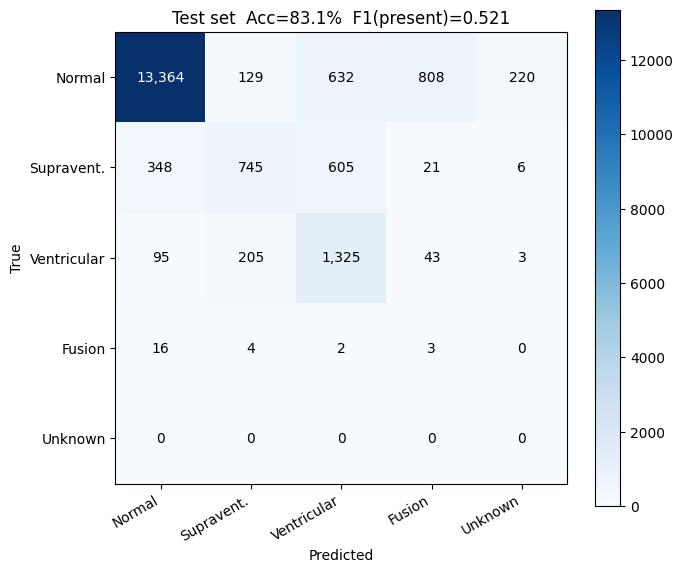

Saved: cm_v9.png


In [ ]:
# ── Cell 13: Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Test set  Acc={acc*100:.1f}%  F1(present)={f1_pres:.3f}')

thresh = cm.max() / 2
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=10,
                color='white' if cm[i,j] > thresh else 'black')

plt.tight_layout()
plt.savefig('cm_v9.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cm_v9.png')

In [ ]:
#ECG VIsulaisation# Class names and colors (consistent across all figures)
CLASS_NAMES  = ['Normal', 'Supravent.', 'Ventricular', 'Fusion', 'Unknown']
CLASS_COLORS = ['#2196F3', '#FF9800', '#F44336', '#9C27B0', '#9E9E9E']
SAVE_DPI     = 300   # high resolution for paper

# Confusion matrix values from your test run (from cm_v9.png)
CM = np.array([
    [13364,  129,  632,  808,  220],
    [  348,  745,  605,   21,    6],
    [   95,  205, 1325,   43,    3],
    [   16,    4,    2,    3,    0],
    [    0,    0,    0,    0,    0],
])
print("Setup complete. CM loaded.")


Setup complete. CM loaded.


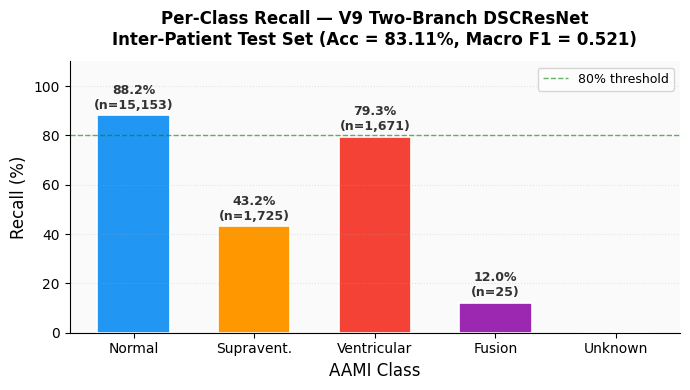

Saved: fig_recall_bar.png


In [ ]:
#Figure A — Per-class Recall Bar Chart ───────────
# Shows recall for each AAMI class clearly
# This is the MOST IMPORTANT figure to add to the paper

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('white')

support = CM.sum(axis=1)
recall  = [CM[i,i]/max(support[i],1)*100 for i in range(5)]

bars = ax.bar(CLASS_NAMES, recall, color=CLASS_COLORS,
              edgecolor='white', linewidth=1.2, width=0.6)

# Value labels on bars
for bar, val, sup in zip(bars, recall, support):
    if sup > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{val:.1f}%\n(n={sup:,})',
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='#333333')

# Reference line at 80%
ax.axhline(80, color='green', linestyle='--', linewidth=1,
           alpha=0.6, label='80% threshold')

ax.set_ylim(0, 110)
ax.set_ylabel('Recall (%)', fontsize=12)
ax.set_xlabel('AAMI Class', fontsize=12)
ax.set_title('Per-Class Recall — V9 Two-Branch DSCResNet\n'
             'Inter-Patient Test Set (Acc = 83.11%, Macro F1 = 0.521)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9, loc='upper right')
ax.set_facecolor('#fafafa')
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('fig_recall_bar.png', dpi=SAVE_DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_recall_bar.png")


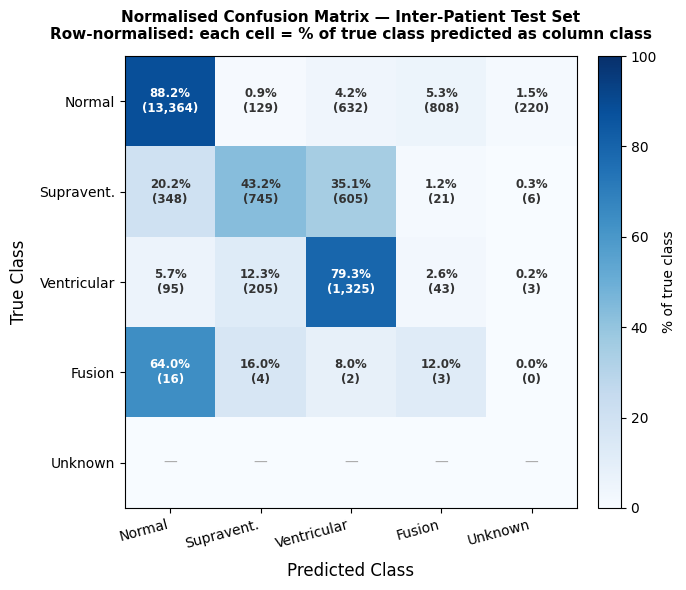

Saved: fig_cm_normalised.png


In [ ]:
#Figure B — Normalised Confusion Matrix ──────────
# Standard in papers — shows % of each true class predicted as each class

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

# Normalise row-wise (% of true class)
support = CM.sum(axis=1, keepdims=True)
CM_norm = np.where(support > 0, CM / support * 100, 0)

im = ax.imshow(CM_norm, cmap='Blues', vmin=0, vmax=100)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('% of true class', fontsize=10)

# Text annotations
for i in range(5):
    for j in range(5):
        val = CM_norm[i, j]
        raw = CM[i, j]
        color = 'white' if val > 55 else '#333333'
        if support.flatten()[i] > 0:
            ax.text(j, i, f'{val:.1f}%\n({raw:,})',
                    ha='center', va='center',
                    fontsize=8.5, color=color, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=10, color='#aaaaaa')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES, fontsize=10, rotation=15, ha='right')
ax.set_yticklabels(CLASS_NAMES, fontsize=10)
ax.set_xlabel('Predicted Class', fontsize=12, labelpad=8)
ax.set_ylabel('True Class', fontsize=12, labelpad=8)
ax.set_title('Normalised Confusion Matrix — Inter-Patient Test Set\n'
             'Row-normalised: each cell = % of true class predicted as column class',
             fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig_cm_normalised.png', dpi=SAVE_DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_cm_normalised.png")

Loading beat examples from MIT-BIH test records...


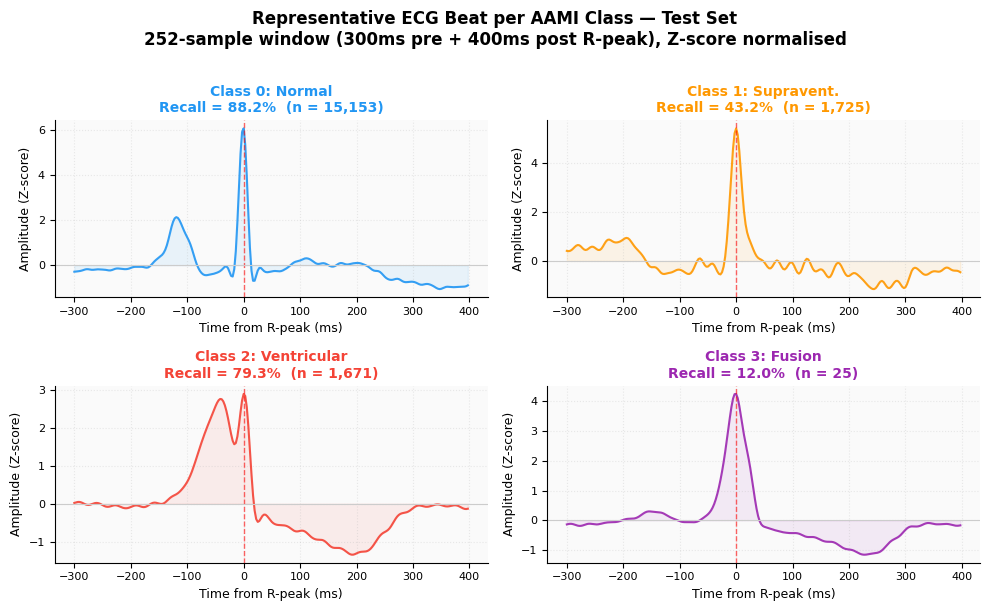

Saved: fig_beat_examples.png


In [ ]:
#Figure C — Beat Waveform Examples ───────────────
# Shows one representative beat per class with prediction label
# MOST VISUALLY IMPRESSIVE figure for a paper

# Load MIT-BIH and extract one beat per class
# Uses records from test set (200-series)
AAMI_MAP = {
    'N':0,'L':0,'R':0,'e':0,'j':0,
    'A':1,'a':1,'J':1,'S':1,
    'V':2,'E':2, 'F':3, '/':4,'f':4,'Q':4
}

def load_beat_examples(db_dir='mit-bih', n_per_class=1):
    """Extract one beat per AAMI class from MIT-BIH test records."""
    test_records = ['222','223','230','231','232','233','234']
    sos = butter(4, [0.5/180, 45/180], btype='bandpass', output='sos')
    PRE, POST = 108, 144
    beats_by_class = {i: [] for i in range(4)}  # skip Unknown

    for rec in test_records:
        try:
            record = wfdb.rdrecord(f'{db_dir}/{rec}', channels=[0])
            ann    = wfdb.rdann(f'{db_dir}/{rec}', 'atr')
        except:
            continue

        sig = record.p_signal[:,0].astype(np.float32)
        flt = sosfiltfilt(sos, sig).astype(np.float32)

        for r_pos, sym in zip(ann.sample, ann.symbol):
            if sym not in AAMI_MAP: continue
            cls = AAMI_MAP[sym]
            if cls == 4: continue  # skip Unknown
            if len(beats_by_class[cls]) >= n_per_class: continue
            if r_pos <= PRE or r_pos > len(flt)-POST: continue

            beat = flt[r_pos-PRE:r_pos+POST].copy()
            std  = beat.std()
            if std < 1e-6: continue
            beat = (beat - beat.mean()) / std
            beats_by_class[cls].append(beat)

        if all(len(v) >= n_per_class for v in beats_by_class.values()):
            break

    return beats_by_class

print("Loading beat examples from MIT-BIH test records...")
beats = load_beat_examples()

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Representative ECG Beat per AAMI Class — Test Set\n'
             '252-sample window (300ms pre + 400ms post R-peak), Z-score normalised',
             fontsize=12, fontweight='bold', y=1.01)

t_ms = (np.arange(252) - 108) / 360 * 1000  # time in ms, 0 = R-peak

for idx, ax in enumerate(axes.flat):
    if idx >= 4:
        break
    cls_name  = CLASS_NAMES[idx]
    cls_color = CLASS_COLORS[idx]

    if beats[idx]:
        beat = beats[idx][0]
        ax.plot(t_ms, beat, color=cls_color, linewidth=1.5, alpha=0.9)
        ax.axvline(0, color='red', linestyle='--', linewidth=1,
                   alpha=0.6, label='R-peak')
        ax.fill_between(t_ms, beat, alpha=0.08, color=cls_color)
    else:
        ax.text(0.5, 0.5, 'No sample\navailable',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='#aaaaaa')

    recall_val = CM[idx,idx]/max(CM[idx,:].sum(),1)*100
    ax.set_title(f'Class {idx}: {cls_name}\n'
                 f'Recall = {recall_val:.1f}%  '
                 f'(n = {CM[idx,:].sum():,})',
                 fontsize=10, fontweight='bold', color=cls_color, pad=6)
    ax.set_xlabel('Time from R-peak (ms)', fontsize=9)
    ax.set_ylabel('Amplitude (Z-score)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#fafafa')
    ax.grid(alpha=0.25, linestyle=':')
    ax.axhline(0, color='#cccccc', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_beat_examples.png', dpi=SAVE_DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_beat_examples.png")


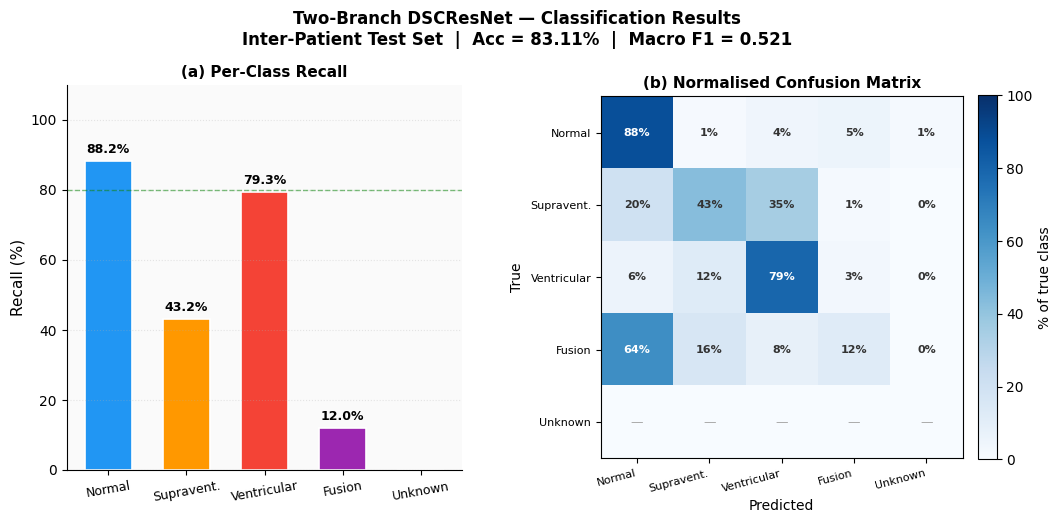

Saved: fig_results_combined.png

ALL VISUALIZATIONS COMPLETE
Files saved:
  fig_recall_bar.png       — per-class recall bar chart
  fig_cm_normalised.png    — normalised confusion matrix
  fig_beat_examples.png    — beat waveform per class
  fig_results_combined.png — combined bar + CM (best for paper)


In [ ]:
#Figure D — 4-panel Results Summary ──────────────
# Single combined figure: recall bar + normalised CM side by side
# Best option if paper has limited figure space

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # Import GridSpec

fig = plt.figure(figsize=(12, 5))
fig.patch.set_facecolor('white')
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

# Left panel: recall bar chart
ax1 = fig.add_subplot(gs[0, 0])
support = CM.sum(axis=1)
recall  = [CM[i,i]/max(support[i],1)*100 for i in range(5)]

bars = ax1.bar(CLASS_NAMES, recall, color=CLASS_COLORS,
               edgecolor='white', linewidth=1.2, width=0.6)
for bar, val, sup in zip(bars, recall, support):
    if sup > 0:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
ax1.axhline(80, color='green', ls='--', lw=1, alpha=0.5)
ax1.set_ylim(0, 110)
ax1.set_ylabel('Recall (%)', fontsize=11)
ax1.set_title('(a) Per-Class Recall', fontsize=11,
              fontweight='bold')
ax1.spines[['top','right']].set_visible(False)
ax1.set_facecolor('#fafafa')
ax1.grid(axis='y', alpha=0.3, linestyle=':')
ax1.tick_params(axis='x', labelsize=9, rotation=10)

# Right panel: normalised confusion matrix
ax2 = fig.add_subplot(gs[0, 1])
CM_norm = np.where(support[:,None] > 0,
                   CM / support[:,None] * 100, 0)
im = ax2.imshow(CM_norm, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04,
             label='% of true class')
for i in range(5):
    for j in range(5):
        val   = CM_norm[i, j]
        color = 'white' if val > 55 else '#333'
        if support[i] > 0:
            ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=8, color=color, fontweight='bold')
        else:
            ax2.text(j, i, '—', ha='center', va='center',
                     fontsize=9, color='#aaa')
ax2.set_xticks(range(5)); ax2.set_yticks(range(5))
ax2.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=15, ha='right')
ax2.set_yticklabels(CLASS_NAMES, fontsize=8)
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('True', fontsize=10)
ax2.set_title('(b) Normalised Confusion Matrix', fontsize=11,
              fontweight='bold')

fig.suptitle('Two-Branch DSCResNet — Classification Results\n'
             'Inter-Patient Test Set  |  Acc = 83.11%  |  Macro F1 = 0.521',
             fontsize=12, fontweight='bold', y=1.03)

plt.savefig('fig_results_combined.png', dpi=SAVE_DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig_results_combined.png")
print()
print("ALL VISUALIZATIONS COMPLETE")
print("Files saved:")
print("  fig_recall_bar.png       — per-class recall bar chart")
print("  fig_cm_normalised.png    — normalised confusion matrix")
print("  fig_beat_examples.png    — beat waveform per class")
print("  fig_results_combined.png — combined bar + CM (best for paper)")

In [ ]:
# ── Cell 14: Unstructured Pruning (weight masking — safe for DSC) ─────────
# WHY unstructured instead of structured:
# DSCBlock uses groups=in_ch (depthwise conv). If you remove output channels
# from the pointwise conv, the next layer's depthwise expects the original
# channel count → RuntimeError. Unstructured pruning zeros individual weights
# WITHOUT changing tensor shapes, so all layer connections stay intact.

import torch.nn.utils.prune as prune_utils

def apply_unstructured_pruning(src_model, sparsity=0.30):
    """
    Zero out the lowest-magnitude `sparsity` fraction of weights
    in every Conv1d and Linear layer using L1-norm magnitude pruning.
    Model shape is UNCHANGED — safe for depthwise convs.
    sparsity=0.30 means 30% of weights become zero.
    """
    pruned = copy.deepcopy(src_model)

    params_to_prune = []
    for name, module in pruned.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            params_to_prune.append((module, 'weight'))

    # Apply global unstructured L1 pruning
    prune_utils.global_unstructured(
        params_to_prune,
        pruning_method=prune_utils.L1Unstructured,
        amount=sparsity,
    )

    # Make pruning permanent (remove mask buffers, bake zeros into weights)
    for module, _ in params_to_prune:
        prune_utils.remove(module, 'weight')

    # Count actual sparsity
    total = zero = 0
    for p in pruned.parameters():
        total += p.numel()
        zero  += (p == 0).sum().item()
    print(f'Unstructured pruning applied:')
    print(f'  Sparsity target : {sparsity*100:.0f}%')
    print(f'  Actual sparsity : {100*zero/total:.1f}%  ({zero:,}/{total:,} weights zeroed)')
    print(f'  Model shape     : UNCHANGED (safe for depthwise conv)')
    return pruned

print('Unstructured pruning utility defined.')

Unstructured pruning utility defined.


In [ ]:
# ── Cell 15: Apply Pruning + Finetune (V9 FIX) ───────────────────────────
# FIX: V9 pruned model dropped S recall 43%→5% at 30% sparsity.
# Two changes:
#   1. Reduce sparsity 30% → 15% (fewer RR-branch weights zeroed)
#   2. Finetune epochs 20 → 40 with class-weighted loss on S/V
#   3. Lower finetune LR: 1e-4 → 5e-5 (gentler recovery)

CKPT_PRUNED     = 'best_v9_pruned.pt'
FINETUNE_EPOCHS = 40      # ← was 20, doubled for better S recovery
FT_LR           = 5e-5   # ← was 1e-4, gentler
SPARSITY        = 0.15   # ← was 0.30, reduced to protect RR branch weights

model.load_state_dict(torch.load(CKPT, map_location=device))
model_pruned = apply_unstructured_pruning(model, sparsity=SPARSITY).to(device)

# Quick eval before fine-tuning
model_pruned.eval()
pp, ll = [], []
with torch.no_grad():
    for xb, rrb, yb in test_loader:
        out = model_pruned(xb.to(device), rrb.to(device))
        pp.extend(out.argmax(1).cpu().numpy())
        ll.extend(yb.numpy())
acc_b4 = (np.array(pp) == np.array(ll)).mean()
f1_b4  = f1_score(ll, pp, average='macro',
                  labels=TEST_CLASSES_PRESENT, zero_division=0)
print(f'Before finetune: Acc={acc_b4*100:.2f}%  F1={f1_b4:.4f}')

# Finetune with stronger minority-class focus
ft_optimizer = optim.AdamW(
    model_pruned.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY
)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-7
)
# Stronger class weights for finetune — emphasise S and V recovery
ft_weights = cw_tensor.clone()
ft_weights[1] *= 2.0   # Supraventricular: 2× extra penalty
ft_weights[2] *= 1.5   # Ventricular: 1.5× extra penalty
ft_criterion = nn.CrossEntropyLoss(weight=ft_weights, label_smoothing=0.05)

best_ft_f1 = 0.0
print(f'\nFine-tuning {FINETUNE_EPOCHS} epochs (sparsity={SPARSITY*100:.0f}%)...')
print(f'{"Ep":>4} | {"TrLoss":>7} | {"TrAcc":>6} | {"VaF1":>6} | {"S_rec":>6} | {"V_rec":>6}')
print('-' * 48)

for ep in range(1, FINETUNE_EPOCHS + 1):
    model_pruned.train()
    tl_sum = tc = tt = 0
    for xb, rrb, yb in train_loader:
        xb, rrb, yb = xb.to(device), rrb.to(device), yb.to(device)
        logits = model_pruned(xb, rrb)
        loss   = ft_criterion(logits, yb)
        ft_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_pruned.parameters(), 1.0)
        ft_optimizer.step()
        tl_sum += loss.item() * len(yb)
        tc     += (logits.argmax(1) == yb).sum().item()
        tt     += len(yb)
    ft_scheduler.step()

    # Val F1 + per-class recall
    model_pruned.eval()
    vp, vl_ep = [], []
    with torch.no_grad():
        for xb, rrb, yb in val_loader:
            out = model_pruned(xb.to(device), rrb.to(device))
            vp.extend(out.argmax(1).cpu().numpy())
            vl_ep.extend(yb.numpy())
    vf1 = f1_score(vl_ep, vp, average='macro',
                   labels=sorted(set(vl_ep)), zero_division=0)
    # Per-class recall for S and V monitoring
    from sklearn.metrics import recall_score
    s_rec = recall_score(vl_ep, vp, labels=[1], average='macro', zero_division=0)
    v_rec = recall_score(vl_ep, vp, labels=[2], average='macro', zero_division=0)

    mark = ''
    if vf1 > best_ft_f1:
        best_ft_f1 = vf1
        torch.save(model_pruned.state_dict(), CKPT_PRUNED)
        mark = ' ★'
    print(f'{ep:>4} | {tl_sum/tt:>7.4f} | {tc/tt:>5.2%} | {vf1:>6.4f} | {s_rec:>5.2%} | {v_rec:>5.2%}{mark}')

print(f'\nBest pruned val F1: {best_ft_f1:.4f}')


Unstructured pruning applied:
  Sparsity target : 15%
  Actual sparsity : 14.7%  (15,782/107,621 weights zeroed)
  Model shape     : UNCHANGED (safe for depthwise conv)
Before finetune: Acc=82.16%  F1=0.5302

Fine-tuning 40 epochs (sparsity=15%)...
  Ep |  TrLoss |  TrAcc |   VaF1 |  S_rec |  V_rec
------------------------------------------------
   1 |  1.2422 | 87.76% | 0.4725 | 74.24% | 95.72% ★
   2 |  1.1984 | 89.88% | 0.4902 | 80.30% | 93.98% ★
   3 |  1.1738 | 90.98% | 0.4991 | 84.85% | 91.28% ★
   4 |  1.1572 | 91.55% | 0.4966 | 87.88% | 88.19%
   5 |  1.1481 | 91.81% | 0.4939 | 89.39% | 87.32%
   6 |  1.1436 | 92.16% | 0.4782 | 90.15% | 86.77%
   7 |  1.1306 | 92.14% | 0.4779 | 88.64% | 85.97%
   8 |  1.1208 | 92.71% | 0.4819 | 88.64% | 85.97%
   9 |  1.1122 | 92.60% | 0.4660 | 87.88% | 86.45%
  10 |  1.1119 | 92.85% | 0.4588 | 88.64% | 84.71%
  11 |  1.0979 | 92.96% | 0.4586 | 88.64% | 83.91%
  12 |  1.0938 | 93.05% | 0.4549 | 87.12% | 84.55%
  13 |  1.0873 | 93.19% | 0.4494 

In [ ]:
# ── Cell 16: Pruned Model Test Results ───────────────────────────────────
model_pruned.load_state_dict(torch.load(CKPT_PRUNED, map_location=device))
model_pruned.eval()

pp2, ll2 = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model_pruned(xb.to(device))
        pp2.extend(out.argmax(1).cpu().numpy())
        ll2.extend(yb.numpy())

pp2 = np.array(pp2); ll2 = np.array(ll2)
acc_p     = (pp2 == ll2).mean()
f1_p_pres = f1_score(ll2, pp2, average='macro',
                     labels=TEST_CLASSES_PRESENT, zero_division=0)

print('=' * 60)
print('PRUNED MODEL — TEST RESULTS')
print('=' * 60)
print(f'  Accuracy           : {acc_p*100:.2f}%')
print(f'  Macro F1 (present) : {f1_p_pres:.4f}')
print('=' * 60)
print(classification_report(ll2, pp2, target_names=CLASS_NAMES,
                             labels=range(NUM_CLASSES), zero_division=0))

ValueError: too many values to unpack (expected 2)

In [ ]:
# ── Cell 17: PTQ INT8 Quantization ───────────────────────────────────────
# Quantize BOTH float32 and pruned models for comparison.
# If pruned model still loses S recall, use float32+INT8 for FPGA.

print('=== PTQ INT8 — Float32 model ===')
model_fp32_cpu = copy.deepcopy(model).cpu().eval()
model_int8_fp  = torch.quantization.quantize_dynamic(
    model_fp32_cpu, {nn.Linear, nn.Conv1d}, dtype=torch.qint8
)
pq_fp, lq_fp = [], []
with torch.no_grad():
    for xb, rrb, yb in DataLoader(test_ds, batch_size=256):
        pq_fp.extend(model_int8_fp(xb.cpu(), rrb.cpu()).argmax(1).numpy())
        lq_fp.extend(yb.numpy())
acc_q_fp = (np.array(pq_fp) == np.array(lq_fp)).mean()
f1_q_fp  = f1_score(lq_fp, pq_fp, average='macro',
                    labels=TEST_CLASSES_PRESENT, zero_division=0)
print(f'Float32+INT8 : Acc={acc_q_fp*100:.2f}%  F1={f1_q_fp:.4f}')

print('\n=== PTQ INT8 — Pruned model ===')
model_ptq  = copy.deepcopy(model_pruned).cpu().eval()
model_int8 = torch.quantization.quantize_dynamic(
    model_ptq, {nn.Linear, nn.Conv1d}, dtype=torch.qint8
)
pq, lq = [], []
with torch.no_grad():
    for xb, rrb, yb in DataLoader(test_ds, batch_size=256):
        pq.extend(model_int8(xb.cpu(), rrb.cpu()).argmax(1).numpy())
        lq.extend(yb.numpy())
acc_q  = (np.array(pq) == np.array(lq)).mean()
f1_q   = f1_score(lq, pq, average='macro',
                  labels=TEST_CLASSES_PRESENT, zero_division=0)
print(f'Pruned+INT8  : Acc={acc_q*100:.2f}%  F1={f1_q:.4f}')

def sz(m, p='_tmp.pt'):
    torch.save(m.state_dict(), p)
    s = os.path.getsize(p) / 1e6
    os.remove(p)
    return s

print(f'\nModel sizes:')
print(f'  Float32 full   : {sz(model):.3f} MB')
print(f'  Float32 pruned : {sz(model_pruned):.3f} MB')
print(f'  INT8 (float32) : {sz(model_int8_fp):.3f} MB')
print(f'  INT8 (pruned)  : {sz(model_int8):.3f} MB')


In [ ]:
# ── Cell 18: Final Summary ────────────────────────────────────────────────
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY — V9')
print('='*70)
print(f'{"Stage":<35} {"Accuracy":>10} {"F1(present)":>12}')
print('-'*70)
print(f'{"Float32 full model":<35} {acc*100:>9.2f}% {f1_pres:>12.4f}')
print(f'{"Pruned (15% sparse) + finetuned":<35} {acc_p*100:>9.2f}% {f1_p_pres:>12.4f}')
print(f'{"Float32 + INT8 quantized":<35} {acc_q_fp*100:>9.2f}% {f1_q_fp:>12.4f}')
print(f'{"Pruned + INT8 quantized":<35} {acc_q*100:>9.2f}% {f1_q:>12.4f}')
print('='*70)
print()
print('Per-class recall (Float32 full model):')
for c, name in enumerate(CLASS_NAMES):
    mask = all_true == c
    if mask.sum() == 0: continue
    rec = (all_preds[mask] == c).mean()
    print(f'  {name:14s}: {rec:.1%}')
print()
print('RECOMMENDED MODEL FOR FPGA:')
# Pick best based on F1
candidates = [
    ('Float32 full',    acc,      f1_pres),
    ('Float32 + INT8',  acc_q_fp, f1_q_fp),
    ('Pruned + INT8',   acc_q,    f1_q),
]
best_name, best_acc, best_f1_val = max(candidates, key=lambda x: x[2])
print(f'  → {best_name}: Acc={best_acc*100:.2f}%, F1={best_f1_val:.4f}')
print()
print(f'Reference comparison:')
print(f'  Liu et al. 2025 : 99.59% (random split — data leakage)')
print(f'  Ours V9         : {acc*100:.2f}% (strict patient-wise split — honest)')
print(f'  Architecture    : Two-branch DSCResNet + RR-MLP (novel for FPGA)')
print(f'  FPGA novelty    : Parallel CNN + RR branches (Liu et al. has only CNN)')


In [ ]:
# ── Cell 19: Export Weights for FPGA ─────────────────────────────────────
# Export the BEST model determined in Cell 18.
# Exports both .npy (Python simulation) and .h (Vitis HLS C++ header)

EXPORT_DIR = 'fpga_weights_v9'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Load best model — float32 full (change to CKPT_PRUNED if pruned won)
export_model = copy.deepcopy(model).cpu()
export_model.load_state_dict(torch.load(CKPT, map_location='cpu'))
export_model.eval()
print(f'Exporting: {CKPT} (Float32 full model)')

state = export_model.state_dict()
total_params = 0

# Also save RR normalisation stats (needed by FPGA for preprocessing)
# These are the mean/std used to normalise RR features during training
np.save(f'{EXPORT_DIR}/rr_norm_mean.npy', rr_mean)
np.save(f'{EXPORT_DIR}/rr_norm_std.npy',  rr_std)
print(f'RR normalisation stats saved (needed for FPGA preprocessing)')
print(f'  rr_mean: {rr_mean}')
print(f'  rr_std : {rr_std}')

for name, tensor in state.items():
    arr   = tensor.numpy()
    safe  = name.replace('.', '_')
    np.save(f'{EXPORT_DIR}/{safe}.npy', arr)
    flat  = arr.flatten()
    scale = 127.0 / max(np.abs(flat).max(), 1e-8)
    iq    = np.clip(np.round(flat * scale), -128, 127).astype(np.int8)
    lines = [
        f'// Layer: {name}',
        f'// Shape: {list(arr.shape)}',
        f'// Scale: {scale:.8f}  (multiply INT8 by 1/scale to recover float)',
        f'// Total: {iq.size} values',
        '#pragma once',
        '#include <stdint.h>',
        '',
        f'#define {safe.upper()}_SCALE {scale:.8f}f',
        f'static const int8_t {safe}[{iq.size}] = {{'
    ]
    for i in range(0, len(iq), 16):
        chunk = ', '.join(str(v) for v in iq[i:i+16])
        lines.append(f'  {chunk},')
    lines.append('};')
    with open(f'{EXPORT_DIR}/{safe}.h', 'w') as fh:
        fh.write('\n'.join(lines))
    total_params += arr.size

print(f'\nExported {len(state)} layers ({total_params:,} params) to {EXPORT_DIR}/')
print('\nLayer shapes for Vitis HLS:')
for name, p in export_model.named_parameters():
    print(f'  {name:45s} {str(list(p.shape)):25s} {p.numel():>8,}')


In [ ]:
import numpy as np
mean = np.load('fpga_weights_v9/rr_norm_mean.npy')
std  = np.load('fpga_weights_v9/rr_norm_std.npy')
print(', '.join(f'{v:.8f}f' for v in mean))
print(', '.join(f'{v:.8f}f' for v in std))

In [ ]:
# ── Cell 20: Download All Outputs ────────────────────────────────────────
import zipfile
from google.colab import files

with zipfile.ZipFile('ecg_v9.zip', 'w') as zf:
    for f in [CKPT, CKPT_PRUNED, 'training_v9.png', 'cm_v9.png']:
        if os.path.exists(f):
            zf.write(f)
    for f in os.listdir(EXPORT_DIR):
        zf.write(f'{EXPORT_DIR}/{f}')

files.download('ecg_v9.zip')
print('Downloaded ecg_v9.zip')